# EDA Block C: Event-Table Extension Feasibility

This notebook implements point 8 from `docs/plan.md`.

Scope:
- quantify event coverage per `player_appearance_id` for pass, pressure, run, and shot tables
- evaluate checkpoint-level density for causal `last15` and `cumul` windows
- identify event-derived features that are dense enough to justify inclusion
- export a concrete feature extension plan and aggregation-ready candidate list

Protocol note:
- development rows only are used when `data/splits/modeling_row_folds.csv` is available
- all windows are checkpoint-causal and aligned to the leakage audit constraints
- the goal here is feasibility and feature-spec design, not model fitting


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
plt.style.use("ggplot")


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "docs").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing `data/` and `docs/`.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "eda_block_c"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Artifact directory: {ARTIFACT_DIR}")


Project root: /Users/jan/Documents/competitions/hackatons/WEC_26
Artifact directory: /Users/jan/Documents/competitions/hackatons/WEC_26/artifacts/eda_block_c


In [2]:
main_path = DATA_DIR / "players_quarters_final.csv"
split_path = DATA_DIR / "splits" / "modeling_row_folds.csv"

main_full = pd.read_csv(main_path)
if split_path.exists():
    main_with_splits = pd.read_csv(split_path)
    main = main_with_splits[main_with_splits["partition_role"] == "development"].copy()
    print(f"Using development partition for Block C: {len(main):,} rows")
else:
    main = main_full.copy()
    print("No split artifact found. Using full main table.")

checkpoint_map = {
    "H1_15": 15,
    "H1_30": 30,
    "H1_45": 45,
    "H2_15": 60,
    "H2_30": 75,
    "H2_45": 90,
    "ET1_15": 105,
}
period_offsets = {
    "half_1": 0,
    "half_2": 45,
    "extra_time_1": 90,
    "extra_time_2": 105,
}
main["checkpoint_cont_min"] = main["checkpoint"].map(checkpoint_map)

event_files = {
    "pass": "player_appearance_pass.csv",
    "pressure": "player_appearance_behaviour_under_pressure.csv",
    "run": "player_appearance_run.csv",
    "shot": "player_appearance_shot_limited.csv",
}

events = {}
for family, filename in event_files.items():
    df = pd.read_csv(DATA_DIR / filename)
    df["event_cont_min"] = df["period"].map(period_offsets) + pd.to_numeric(df["minute"], errors="coerce")
    events[family] = df


Using development partition for Block C: 2,830 rows


In [3]:
def appearance_coverage_summary(main_df: pd.DataFrame, event_df: pd.DataFrame, family: str) -> dict:
    main_ids = set(main_df["player_appearance_id"].unique())
    event_ids = set(pd.to_numeric(event_df["player_appearance_id"], errors="coerce").dropna().astype(int).unique())
    overlap = main_ids & event_ids
    return {
        "family": family,
        "event_rows": int(len(event_df)),
        "event_unique_player_appearance_id": int(len(event_ids)),
        "main_unique_player_appearance_id": int(len(main_ids)),
        "overlap_player_appearance_id": int(len(overlap)),
        "coverage_rate": float(len(overlap) / len(main_ids)),
        "mean_events_per_overlapping_appearance": float(
            event_df[event_df["player_appearance_id"].isin(overlap)].groupby("player_appearance_id").size().mean()
        ) if overlap else 0.0,
    }


appearance_coverage = pd.DataFrame(
    [appearance_coverage_summary(main, event_df, family) for family, event_df in events.items()]
).sort_values("coverage_rate", ascending=False).reset_index(drop=True)
appearance_coverage.to_csv(ARTIFACT_DIR / "appearance_coverage_summary.csv", index=False)

display(Markdown("## Appearance-Level Event Coverage"))
display(appearance_coverage)


## Appearance-Level Event Coverage

,family,event_rows,event_unique_player_appearance_id,main_unique_player_appearance_id,overlap_player_appearance_id,coverage_rate,mean_events_per_overlapping_appearance
0,pass,29795,959,702,701,0.998575,32.706134
1,run,35133,968,702,693,0.987179,40.034632
2,pressure,12185,923,702,684,0.974359,14.213450
3,shot,780,453,702,356,0.507123,1.769663


In [4]:
def build_window_event_lists(main_df: pd.DataFrame, event_df: pd.DataFrame) -> tuple[list[pd.DataFrame], list[pd.DataFrame]]:
    grouped = {player_id: frame for player_id, frame in event_df.groupby("player_appearance_id", dropna=True)}
    cumulative_windows = []
    last15_windows = []
    for row in main_df[["player_appearance_id", "checkpoint_cont_min"]].itertuples(index=False):
        player_events = grouped.get(row.player_appearance_id)
        if player_events is None:
            cumulative_windows.append(pd.DataFrame(columns=event_df.columns))
            last15_windows.append(pd.DataFrame(columns=event_df.columns))
            continue
        cumulative = player_events[player_events["event_cont_min"] <= row.checkpoint_cont_min]
        last15 = cumulative[cumulative["event_cont_min"] > row.checkpoint_cont_min - 15]
        cumulative_windows.append(cumulative)
        last15_windows.append(last15)
    return cumulative_windows, last15_windows


def checkpoint_window_coverage(main_df: pd.DataFrame, family: str, windows: list[pd.DataFrame], window_name: str) -> pd.DataFrame:
    rows = []
    temp = main_df[["checkpoint"]].copy()
    temp["count"] = [len(window) for window in windows]
    temp["has_events"] = temp["count"] > 0
    grouped = temp.groupby("checkpoint", dropna=False)
    summary = grouped.agg(rows=("checkpoint", "size"), coverage_rate=("has_events", "mean"), mean_event_count=("count", "mean"), median_event_count=("count", "median"))
    summary = summary.reset_index()
    summary["family"] = family
    summary["window"] = window_name
    return summary


window_lists = {}
coverage_rows = []
for family, event_df in events.items():
    cumulative_windows, last15_windows = build_window_event_lists(main, event_df)
    window_lists[family] = {"cumul": cumulative_windows, "last15": last15_windows}
    coverage_rows.append(checkpoint_window_coverage(main, family, cumulative_windows, "cumul"))
    coverage_rows.append(checkpoint_window_coverage(main, family, last15_windows, "last15"))

checkpoint_coverage = pd.concat(coverage_rows, ignore_index=True)
checkpoint_order = ["H1_15", "H1_30", "H1_45", "H2_15", "H2_30", "H2_45", "ET1_15"]
checkpoint_coverage["checkpoint"] = pd.Categorical(checkpoint_coverage["checkpoint"], categories=checkpoint_order, ordered=True)
checkpoint_coverage = checkpoint_coverage.sort_values(["family", "window", "checkpoint"]).reset_index(drop=True)
checkpoint_coverage.to_csv(ARTIFACT_DIR / "checkpoint_window_coverage.csv", index=False)

display(Markdown("## Checkpoint-Level Window Coverage"))
display(checkpoint_coverage)


## Checkpoint-Level Window Coverage

,checkpoint,rows,coverage_rate,mean_event_count,median_event_count,family,window
0,H1_15,549,0.976321,7.460838,6.0,pass,cumul
1,H1_30,549,1.000000,14.278689,13.0,pass,cumul
2,H1_45,549,0.998179,20.969035,19.0,pass,cumul
3,H2_15,549,0.992714,27.056466,24.0,pass,cumul
4,H2_30,549,0.956284,28.777778,26.0,pass,cumul
5,H2_45,43,0.976744,33.651163,33.0,pass,cumul
6,ET1_15,42,0.952381,31.500000,23.5,pass,cumul
7,H1_15,549,0.976321,7.460838,6.0,pass,last15
8,H1_30,549,0.972678,6.817851,6.0,pass,last15
9,H1_45,549,0.976321,6.719490,6.0,pass,last15


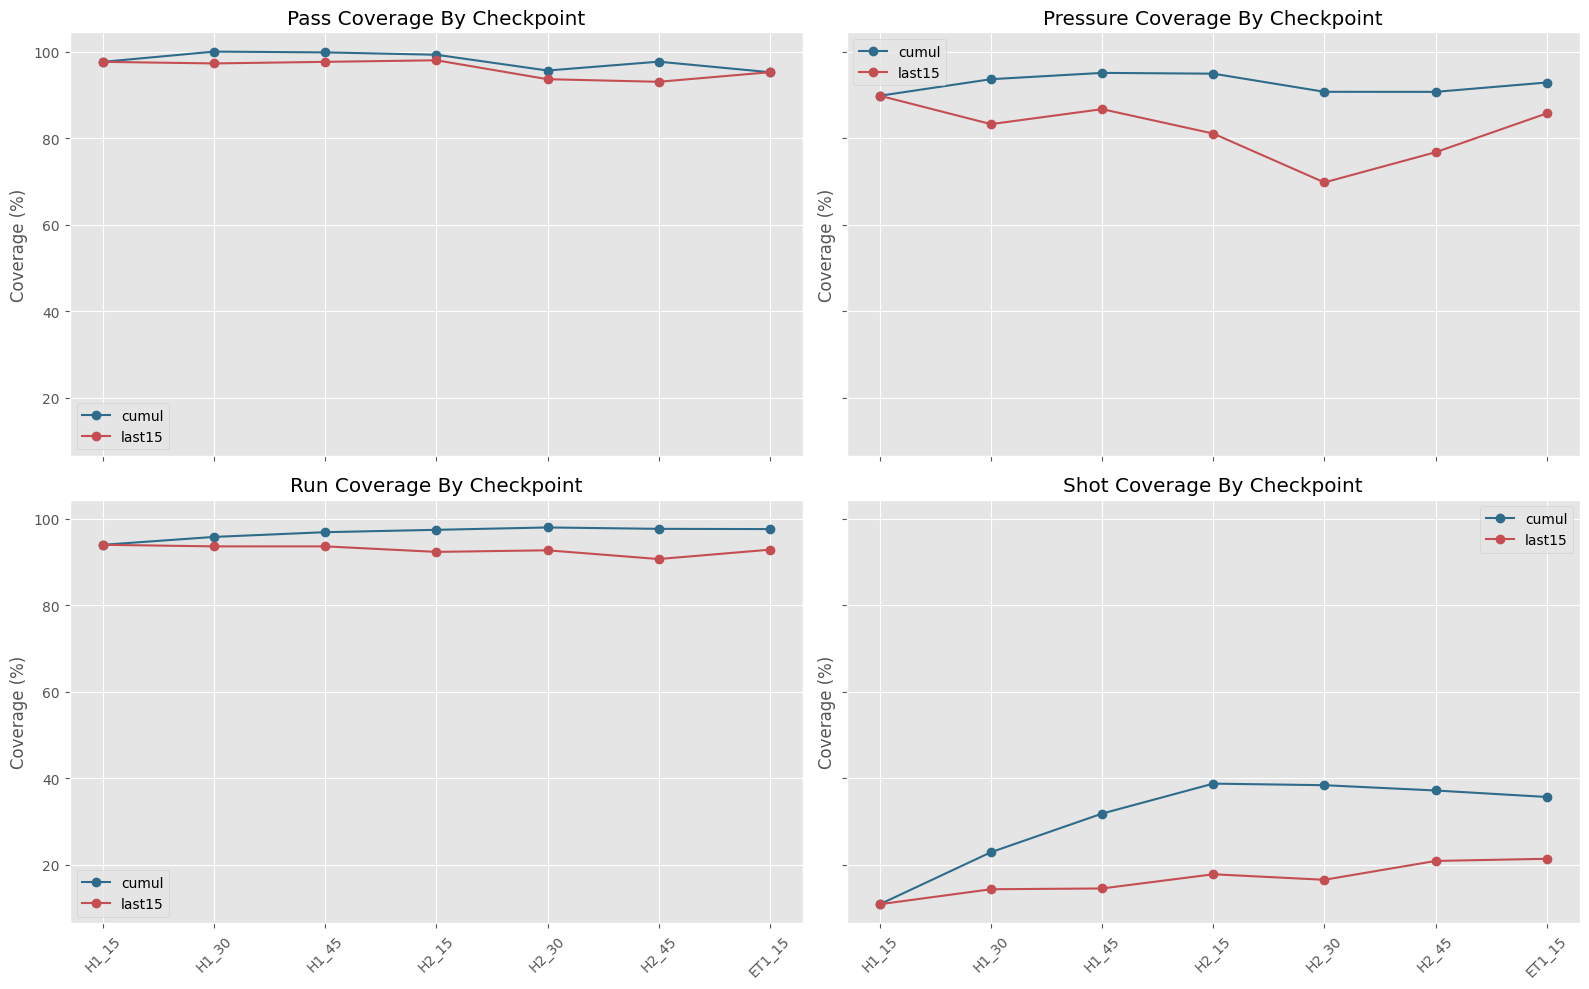

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()
for ax, family in zip(axes, event_files):
    subset = checkpoint_coverage[checkpoint_coverage["family"] == family]
    for window_name, color in [("cumul", "#2f6b8a"), ("last15", "#c44e52")]:
        window_subset = subset[subset["window"] == window_name]
        ax.plot(window_subset["checkpoint"].astype(str), window_subset["coverage_rate"] * 100, marker="o", label=window_name, color=color)
    ax.set_title(f"{family.title()} Coverage By Checkpoint")
    ax.set_ylabel("Coverage (%)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()


In [6]:
def summarize_candidate_features(family: str, windows: dict[str, list[pd.DataFrame]]) -> pd.DataFrame:
    rows = []

    def add_feature(window_name: str, feature_name: str, values: list[float], interpretation: str) -> None:
        series = pd.Series(values)
        rows.append(
            {
                "family": family,
                "window": window_name,
                "feature": feature_name,
                "support_rate": float((series > 0).mean()),
                "mean": float(series.mean()),
                "median": float(series.median()),
                "p90": float(series.quantile(0.9)),
                "interpretation": interpretation,
            }
        )

    for window_name, window_frames in windows.items():
        if family == "pass":
            count = [len(frame) for frame in window_frames]
            accurate_rate = [frame["accurate"].fillna(False).astype(bool).mean() if len(frame) else 0.0 for frame in window_frames]
            top_share = [((frame["stage"] == "top").mean()) if len(frame) else 0.0 for frame in window_frames]
            middle_share = [((frame["stage"] == "middle").mean()) if len(frame) else 0.0 for frame in window_frames]
            add_feature(window_name, "pass_count", count, "passing volume")
            add_feature(window_name, "pass_accurate_rate", accurate_rate, "passing accuracy")
            add_feature(window_name, "pass_top_share", top_share, "share of passes from the top zone")
            add_feature(window_name, "pass_middle_share", middle_share, "share of passes from the middle zone")

        elif family == "pressure":
            count = [len(frame) for frame in window_frames]
            accurate_rate = [frame["accurate"].fillna(False).astype(bool).mean() if len(frame) else 0.0 for frame in window_frames]
            turnover_rate = [((frame["press_induced_outcome"] == "turnover").mean()) if len(frame) else 0.0 for frame in window_frames]
            top_share = [((frame["stage"] == "top").mean()) if len(frame) else 0.0 for frame in window_frames]
            pass_angle_observed_share = [(frame["pass_angle"].notna().mean()) if len(frame) else 0.0 for frame in window_frames]
            add_feature(window_name, "pressure_count", count, "pressure-influenced action volume")
            add_feature(window_name, "pressure_accurate_rate", accurate_rate, "accuracy under pressure")
            add_feature(window_name, "pressure_turnover_rate", turnover_rate, "share of pressured actions ending in turnover")
            add_feature(window_name, "pressure_top_share", top_share, "share of pressured actions in the top zone")
            add_feature(window_name, "pressure_pass_angle_observed_share", pass_angle_observed_share, "share of pressured actions producing a measurable pass angle")

        elif family == "run":
            count = [len(frame) for frame in window_frames]
            sprint_share = [((frame["run_type"] == "sprint").mean()) if len(frame) else 0.0 for frame in window_frames]
            distance_sum = [frame["distance"].sum() if len(frame) else 0.0 for frame in window_frames]
            peak_speed = [frame["max_speed"].max() if len(frame) else 0.0 for frame in window_frames]
            mean_max_speed = [frame["max_speed"].mean() if len(frame) else 0.0 for frame in window_frames]
            top_share = [((frame["stage"] == "top").mean()) if len(frame) else 0.0 for frame in window_frames]
            add_feature(window_name, "run_count", count, "running-event volume")
            add_feature(window_name, "run_sprint_share", sprint_share, "share of runs classified as sprint")
            add_feature(window_name, "run_distance_sum", distance_sum, "total run distance")
            add_feature(window_name, "run_peak_speed", peak_speed, "peak recorded run speed")
            add_feature(window_name, "run_mean_max_speed", mean_max_speed, "mean of run max speeds")
            add_feature(window_name, "run_top_share", top_share, "share of runs in the top zone")

        elif family == "shot":
            cleaned_frames = [frame[frame["own_goal_player_appearance_id"].isna()].copy() if "own_goal_player_appearance_id" in frame.columns else frame.copy() for frame in window_frames]
            count = [len(frame) for frame in cleaned_frames]
            top_share = [((frame["stage"] == "top").mean()) if len(frame) else 0.0 for frame in cleaned_frames]
            under_pressure_rate = [frame["under_pressure"].fillna(False).astype(bool).mean() if len(frame) else 0.0 for frame in cleaned_frames]
            blocked_share = [(frame["block_player_appearance_id"].notna().mean()) if len(frame) else 0.0 for frame in cleaned_frames]
            regular_play_share = [((frame["play_pattern"] == "regular_play").mean()) if len(frame) else 0.0 for frame in cleaned_frames]
            add_feature(window_name, "shot_count", count, "non-own-goal shot volume")
            add_feature(window_name, "shot_top_share", top_share, "share of shots from the top zone")
            add_feature(window_name, "shot_under_pressure_rate", under_pressure_rate, "share of shots under pressure")
            add_feature(window_name, "shot_blocked_share", blocked_share, "share of shots blocked by another player")
            add_feature(window_name, "shot_regular_play_share", regular_play_share, "share of shots from regular play")

    out = pd.DataFrame(rows)
    out["feasibility_band"] = np.select(
        [out["support_rate"] >= 0.60, out["support_rate"] >= 0.20],
        ["core", "conditional"],
        default="sparse",
    )
    return out


candidate_features = pd.concat(
    [summarize_candidate_features(family, windows) for family, windows in window_lists.items()],
    ignore_index=True,
)
candidate_features = candidate_features.sort_values(["family", "window", "support_rate", "feature"], ascending=[True, True, False, True]).reset_index(drop=True)
candidate_features.to_csv(ARTIFACT_DIR / "candidate_event_features.csv", index=False)

display(Markdown("## Candidate Event Features"))
display(candidate_features)


## Candidate Event Features

,family,window,feature,support_rate,mean,median,p90,interpretation,feasibility_band
0,pass,cumul,pass_count,0.984099,20.095406,15.500000,43.000000,passing volume,core
1,pass,cumul,pass_accurate_rate,0.975265,0.821140,0.863636,1.000000,passing accuracy,core
2,pass,cumul,pass_middle_share,0.882686,0.455987,0.500000,0.750000,share of passes from the middle zone,core
3,pass,cumul,pass_top_share,0.707420,0.223107,0.158312,0.562500,share of passes from the top zone,core
4,pass,last15,pass_count,0.967491,6.755830,6.000000,13.000000,passing volume,core
5,pass,last15,pass_accurate_rate,0.947350,0.809114,0.888889,1.000000,passing accuracy,core
6,pass,last15,pass_middle_share,0.798940,0.443774,0.500000,0.842510,share of passes from the middle zone,core
7,pass,last15,pass_top_share,0.551943,0.227032,0.111111,0.666667,share of passes from the top zone,conditional
8,pressure,cumul,pressure_count,0.927915,8.813781,7.000000,19.000000,pressure-influenced action volume,core
9,pressure,cumul,pressure_accurate_rate,0.866078,0.537401,0.577935,0.909091,accuracy under pressure,core


In [7]:
shot_feature_whitelist = {
    "shot_count",
    "shot_top_share",
    "shot_under_pressure_rate",
    "shot_regular_play_share",
}

robust_shortlist = candidate_features[
    (
        ((candidate_features["family"] != "shot") & (candidate_features["feasibility_band"] == "core"))
        | (
            (candidate_features["family"] == "shot")
            & (candidate_features["feature"].isin(shot_feature_whitelist))
            & (candidate_features["support_rate"] >= 0.10)
        )
    )
].copy()
robust_shortlist["inclusion_recommendation"] = np.select(
    [
        robust_shortlist["family"].isin(["pass", "pressure", "run"]),
        robust_shortlist["family"] == "shot",
    ],
    ["include_in_extension_v1", "include_selectively"],
    default="review",
)
robust_shortlist = robust_shortlist.sort_values(["family", "window", "support_rate"], ascending=[True, True, False]).reset_index(drop=True)
robust_shortlist.to_csv(ARTIFACT_DIR / "robust_event_feature_shortlist.csv", index=False)

display(Markdown("## Robust Event Feature Shortlist"))
display(robust_shortlist)


## Robust Event Feature Shortlist

,family,window,feature,support_rate,mean,median,p90,interpretation,feasibility_band,inclusion_recommendation
0,pass,cumul,pass_count,0.984099,20.095406,15.500000,43.000000,passing volume,core,include_in_extension_v1
1,pass,cumul,pass_accurate_rate,0.975265,0.821140,0.863636,1.000000,passing accuracy,core,include_in_extension_v1
2,pass,cumul,pass_middle_share,0.882686,0.455987,0.500000,0.750000,share of passes from the middle zone,core,include_in_extension_v1
3,pass,cumul,pass_top_share,0.707420,0.223107,0.158312,0.562500,share of passes from the top zone,core,include_in_extension_v1
4,pass,last15,pass_count,0.967491,6.755830,6.000000,13.000000,passing volume,core,include_in_extension_v1
5,pass,last15,pass_accurate_rate,0.947350,0.809114,0.888889,1.000000,passing accuracy,core,include_in_extension_v1
6,pass,last15,pass_middle_share,0.798940,0.443774,0.500000,0.842510,share of passes from the middle zone,core,include_in_extension_v1
7,pressure,cumul,pressure_count,0.927915,8.813781,7.000000,19.000000,pressure-influenced action volume,core,include_in_extension_v1
8,pressure,cumul,pressure_accurate_rate,0.866078,0.537401,0.577935,0.909091,accuracy under pressure,core,include_in_extension_v1
9,pressure,cumul,pressure_pass_angle_observed_share,0.851237,0.499118,0.500000,0.857143,share of pressured actions producing a measura...,core,include_in_extension_v1


## Feasibility Counts By Family And Window

feasibility_band,family,window,conditional,core,sparse
0,pass,cumul,0,4,0
1,pass,last15,1,3,0
2,pressure,cumul,0,5,0
3,pressure,last15,2,3,0
4,run,cumul,0,6,0
5,run,last15,0,6,0
6,shot,cumul,4,0,1
7,shot,last15,0,0,5


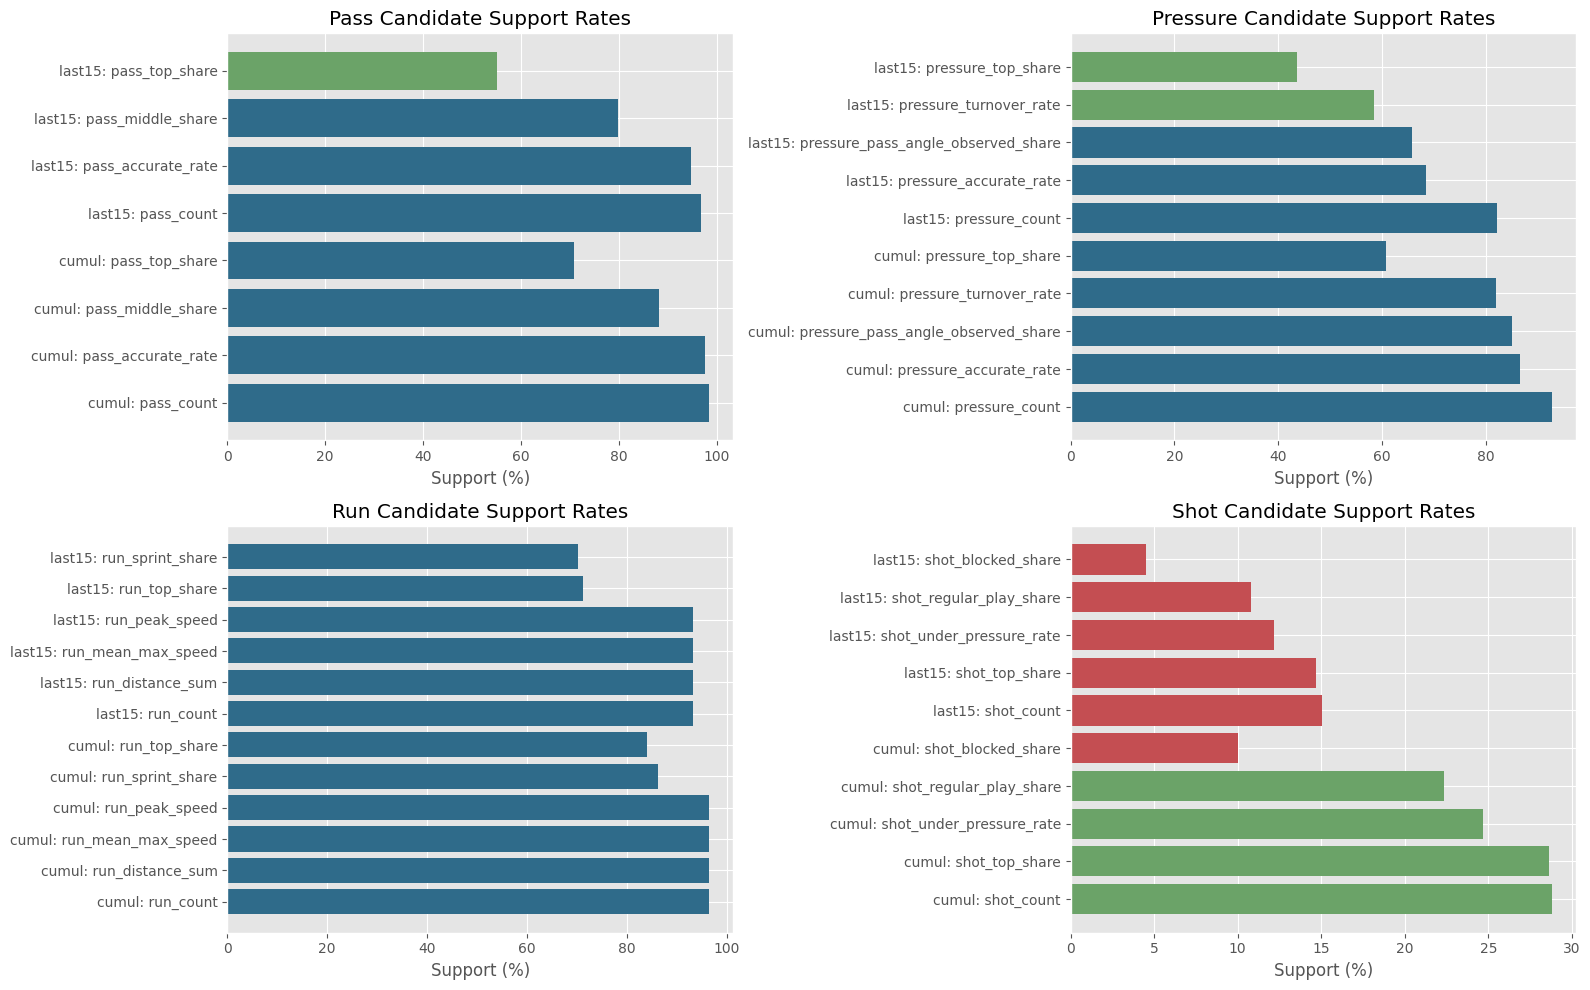

In [8]:
family_window_summary = (
    candidate_features.groupby(["family", "window", "feasibility_band"], dropna=False)
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

display(Markdown("## Feasibility Counts By Family And Window"))
display(family_window_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
for ax, family in zip(axes, event_files):
    subset = candidate_features[candidate_features["family"] == family].copy()
    subset["label"] = subset["window"] + ": " + subset["feature"]
    ax.barh(subset["label"], subset["support_rate"] * 100, color=np.where(subset["feasibility_band"] == "core", "#2f6b8a", np.where(subset["feasibility_band"] == "conditional", "#6ba368", "#c44e52")))
    ax.set_title(f"{family.title()} Candidate Support Rates")
    ax.set_xlabel("Support (%)")
plt.tight_layout()
plt.show()


## Interpretation Notes

- pass, pressure, and run families have enough density for meaningful checkpoint-level extensions in both `cumul` and `last15` windows
- shot-derived extensions are much sparser than the other families, so only a compact set of shot features should be added at first
- sparse shot descriptors such as blocked-share subtypes should be deferred until baseline incremental value is established
- all downstream feature engineering should use the same continuous-minute checkpoint alignment defined here and in the event aggregation specification
